In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tmdb_cleaned.csv")

In [7]:
df.shape

(822873, 19)

In [17]:
df.dtypes

id                     int64
title                 object
status                object
original_title        object
release_date          object
release_year         float64
vote_average         float64
vote_count           float64
runtime              float64
budget               float64
revenue              float64
original_language     object
genres                object
cast                  object
director              object
overview              object
tagline               object
popularity           float64
tags                  object
dtype: object

In [31]:
df.head()

,id,title,status,original_title,release_date,release_year,vote_average,vote_count,runtime,budget,revenue,original_language,genres,cast,director,overview,tagline,popularity,tags
0,2,Ariel,Released,Ariel,1988-10-21,1988.0,7.106,371.0,73.0,0.0,0.0,fi,"Comedy, Drama, Romance, Crime","Kari Helaseppä, Jaakko Talaskivi, Mikko Remes,...",Aki Kaurismäki,A Finnish man goes to the city to find a job a...,NaN,1.6384,"comedy, drama, romance, crime kari helaseppä, ..."
1,3,Shadows in Paradise,Released,Varjoja paratiisissa,1986-10-17,1986.0,7.300,435.0,74.0,0.0,0.0,fi,"Comedy, Drama, Romance","Ari Korhonen, Mari Rantasila, Erkki Rissanen, ...",Aki Kaurismäki,"Nikander, a rubbish collector and would-be ent...",NaN,2.7136,"comedy, drama, romance ari korhonen, mari rant..."
2,5,Four Rooms,Released,Four Rooms,1995-12-09,1995.0,5.900,2821.0,98.0,4000000.0,4257354.0,en,Comedy,"David Proval, Tamlyn Tomita, Paul Skemp, Lana ...","Quentin Tarantino, Robert Rodriguez, Alexandre...",It's Ted the Bellhop's first night on the job....,Twelve outrageous guests. Four scandalous requ...,4.0661,"comedy david proval, tamlyn tomita, paul skemp..."
3,6,Judgment Night,Released,Judgment Night,1993-10-15,1993.0,6.500,370.0,109.0,21000000.0,12136938.0,en,"Action, Crime, Thriller","Jeremy Piven, Lydell M. Cheshier, Michael DeLo...",Stephen Hopkins,"Four young friends, while taking a shortcut en...",Don't move. Don't whisper. Don't even breathe.,2.1596,"action, crime, thriller jeremy piven, lydell m..."
4,8,Life in Loops (A Megacities RMX),Released,Life in Loops (A Megacities RMX),2006-01-01,2006.0,7.200,30.0,80.0,42000.0,0.0,en,Documentary,NaN,Timo Novotny,Timo Novotny labels his new project an experim...,A Megacities remix.,2.2585,documentary timo novotny timo novotny labels ...


In [23]:
df.isnull().sum()



id                        0
title                     0
status                    0
original_title            0
release_date              0
release_year              0
vote_average              0
vote_count                0
runtime                   0
budget                    0
revenue                   0
original_language         0
genres               159521
cast                 214654
director              74610
overview                  0
tagline              666834
popularity                0
tags                      0
dtype: int64

In [29]:
df.duplicated().sum()

0

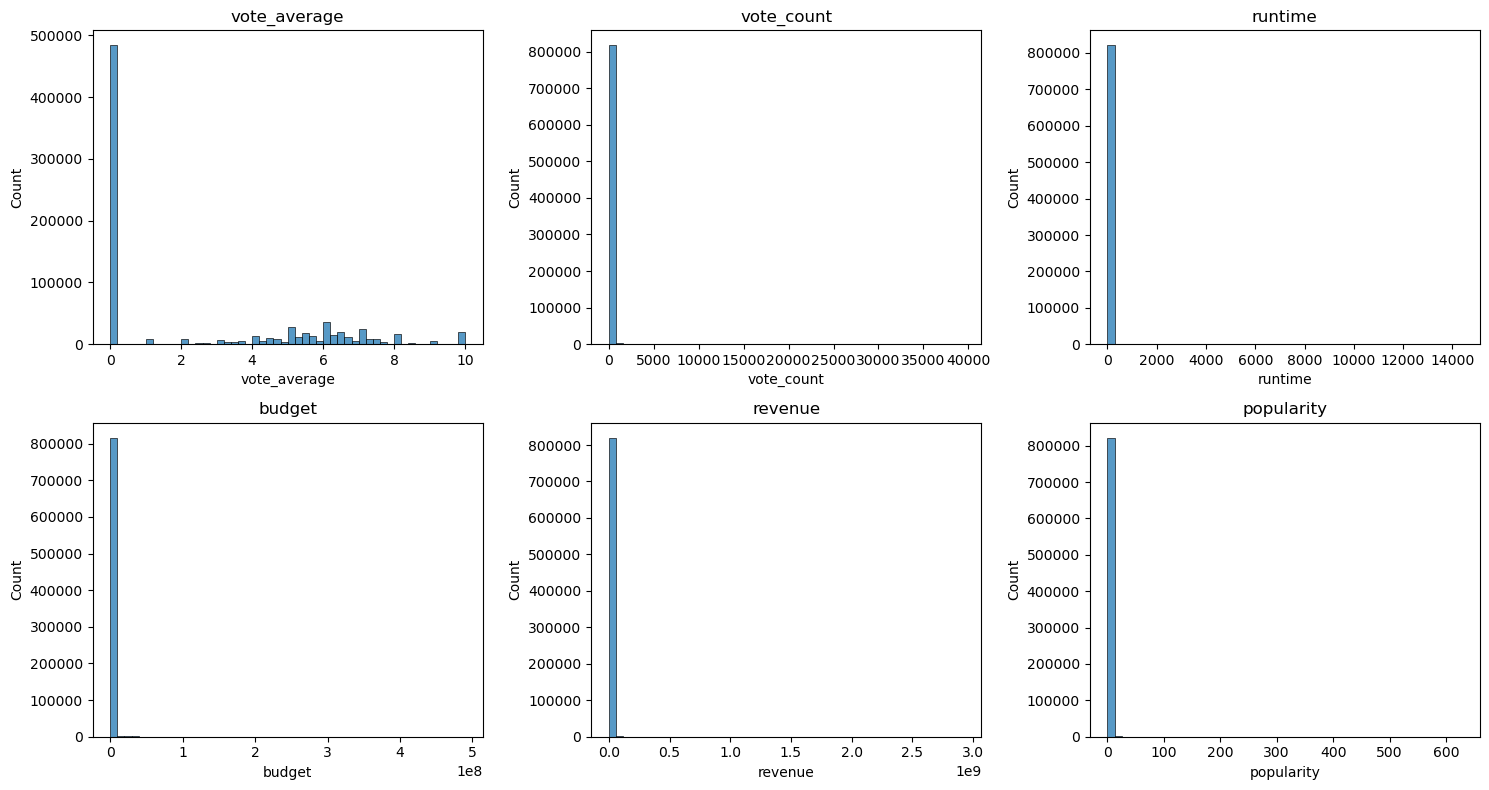

In [33]:
num_cols = ["vote_average", "vote_count", "runtime", "budget", "revenue", "popularity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=50, ax=ax)
    ax.set_title(col)

plt.tight_layout()

In [35]:
import numpy as np

zero_as_missing_cols = ["budget", "revenue", "runtime"]

for col in zero_as_missing_cols:
    df[col] = df[col].replace(0, np.nan)

print(df[zero_as_missing_cols].isna().sum())

budget     763675
revenue    798595
runtime         0
dtype: int64


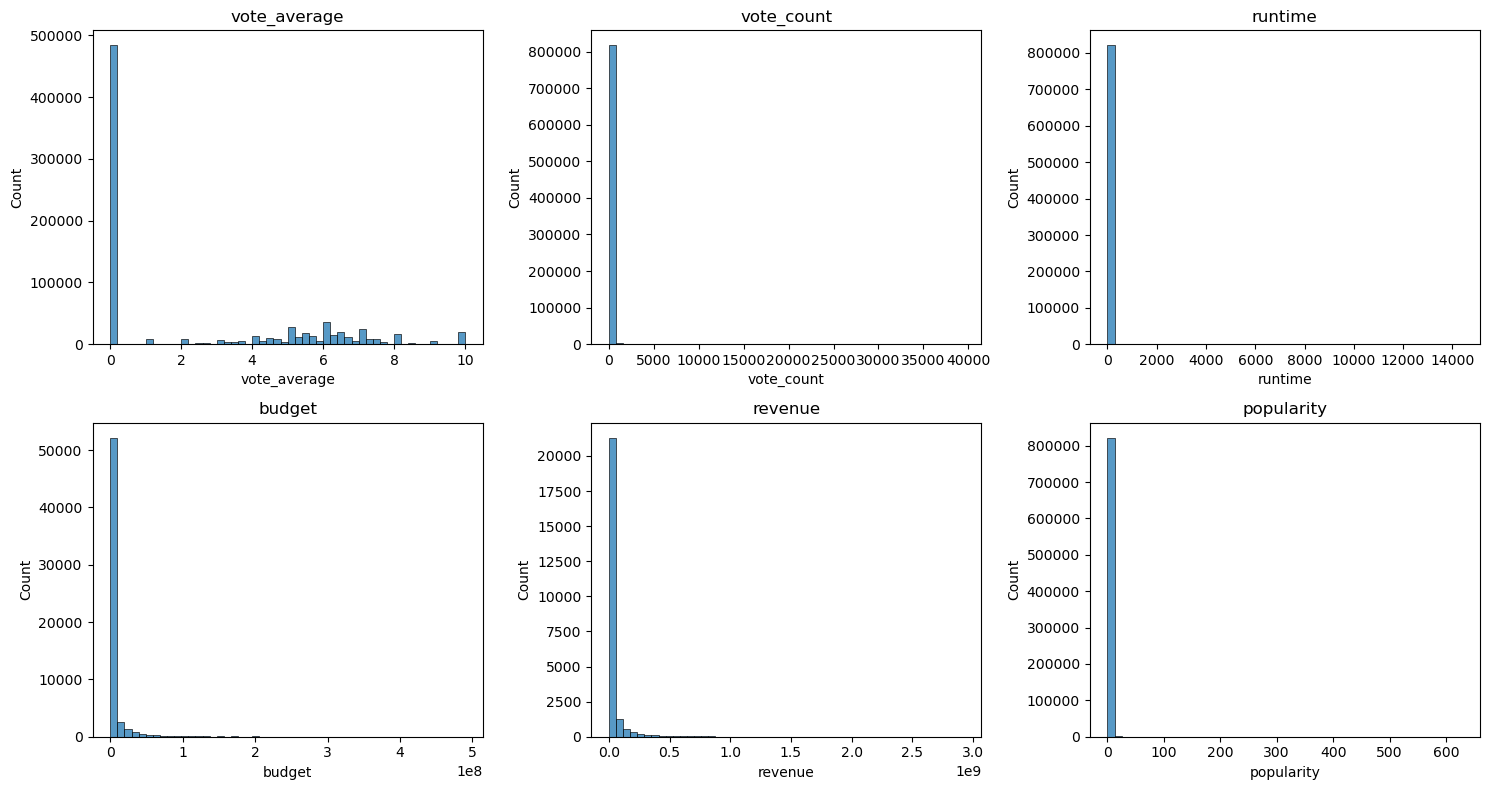

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["vote_average", "vote_count", "runtime", "budget", "revenue", "popularity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

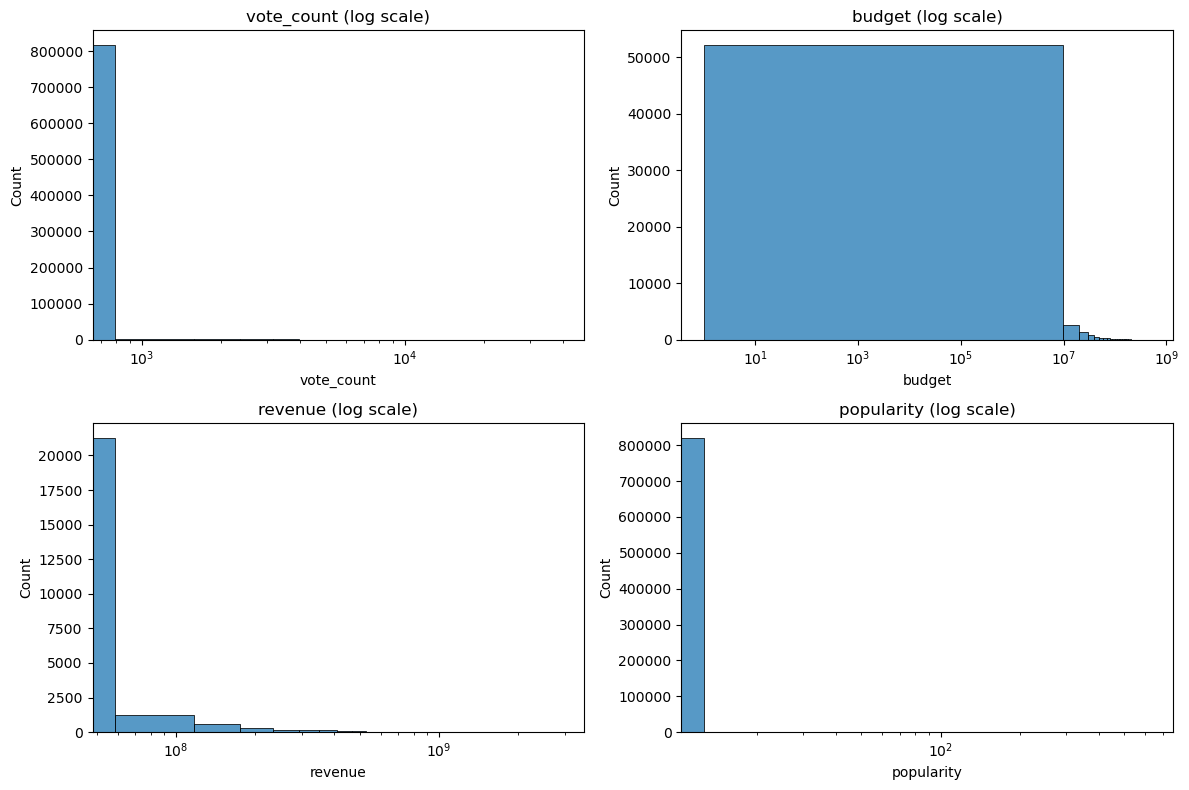

In [39]:
skewed_cols = ["vote_count", "budget", "revenue", "popularity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, skewed_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_xscale("log")
    ax.set_title(f"{col} (log scale)")

plt.tight_layout()
plt.show()

In [45]:
df.head(-10)

,id,title,status,original_title,release_date,release_year,vote_average,vote_count,runtime,budget,revenue,original_language,genres,cast,director,overview,tagline,popularity,tags
0,2,Ariel,Released,Ariel,1988-10-21,1988.0,7.106,371.0,73.0,NaN,NaN,fi,"Comedy, Drama, Romance, Crime","Kari Helaseppä, Jaakko Talaskivi, Mikko Remes,...",Aki Kaurismäki,A Finnish man goes to the city to find a job a...,NaN,1.6384,"comedy, drama, romance, crime kari helaseppä, ..."
1,3,Shadows in Paradise,Released,Varjoja paratiisissa,1986-10-17,1986.0,7.300,435.0,74.0,NaN,NaN,fi,"Comedy, Drama, Romance","Ari Korhonen, Mari Rantasila, Erkki Rissanen, ...",Aki Kaurismäki,"Nikander, a rubbish collector and would-be ent...",NaN,2.7136,"comedy, drama, romance ari korhonen, mari rant..."
2,5,Four Rooms,Released,Four Rooms,1995-12-09,1995.0,5.900,2821.0,98.0,4000000.0,4257354.0,en,Comedy,"David Proval, Tamlyn Tomita, Paul Skemp, Lana ...","Quentin Tarantino, Robert Rodriguez, Alexandre...",It's Ted the Bellhop's first night on the job....,Twelve outrageous guests. Four scandalous requ...,4.0661,"comedy david proval, tamlyn tomita, paul skemp..."
3,6,Judgment Night,Released,Judgment Night,1993-10-15,1993.0,6.500,370.0,109.0,21000000.0,12136938.0,en,"Action, Crime, Thriller","Jeremy Piven, Lydell M. Cheshier, Michael DeLo...",Stephen Hopkins,"Four young friends, while taking a shortcut en...",Don't move. Don't whisper. Don't even breathe.,2.1596,"action, crime, thriller jeremy piven, lydell m..."
4,8,Life in Loops (A Megacities RMX),Released,Life in Loops (A Megacities RMX),2006-01-01,2006.0,7.200,30.0,80.0,42000.0,NaN,en,Documentary,NaN,Timo Novotny,Timo Novotny labels his new project an experim...,A Megacities remix.,2.2585,documentary timo novotny timo novotny labels ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822858,1682677,La Región Invisible,Released,La Región Invisible,2010-01-01,2010.0,0.000,0.0,19.0,NaN,NaN,es,NaN,"Ana Cecilia Natteri, Nicolás Fantinato",Aldo Salvini,Resentment can reach absurd and malevolent ext...,NaN,0.0000,"ana cecilia natteri, nicolás fantinato aldo s..."
822859,1682679,Simcha,Released,Simcha,2024-12-27,2024.0,0.000,0.0,25.0,NaN,NaN,en,"Comedy, Drama, Horror","Leroy Tzarfati, Yaara Ohayon, Naama Shitrit, D...",Tomer Weinberg,Simcha is a dust monster who has lived for yea...,NaN,0.0000,"comedy, drama, horror leroy tzarfati, yaara oh..."
822860,1682682,Exhibition Gala | ISU World Championships | He...,Released,Exhibition Gala | ISU World Championships | He...,2017-04-02,2017.0,0.000,0.0,155.0,NaN,NaN,en,NaN,"Evgenia Medvedeva, Scott Moir, Sui Wenjing, Yu...",NaN,Stars from the figure skating world championsh...,NaN,0.0000,"evgenia medvedeva, scott moir, sui wenjing, y..."
822861,1682689,Meet Me at the End,Released,Meet Me at the End,2026-05-26,2026.0,0.000,0.0,14.0,6000.0,NaN,en,Drama,"Kathleen Wilce, Abby Smook, Eve Guttman, Alexa...",Natalie Mahoney,A teenage girl comes to a crossroads when she'...,NaN,0.0000,"drama kathleen wilce, abby smook, eve guttman,..."


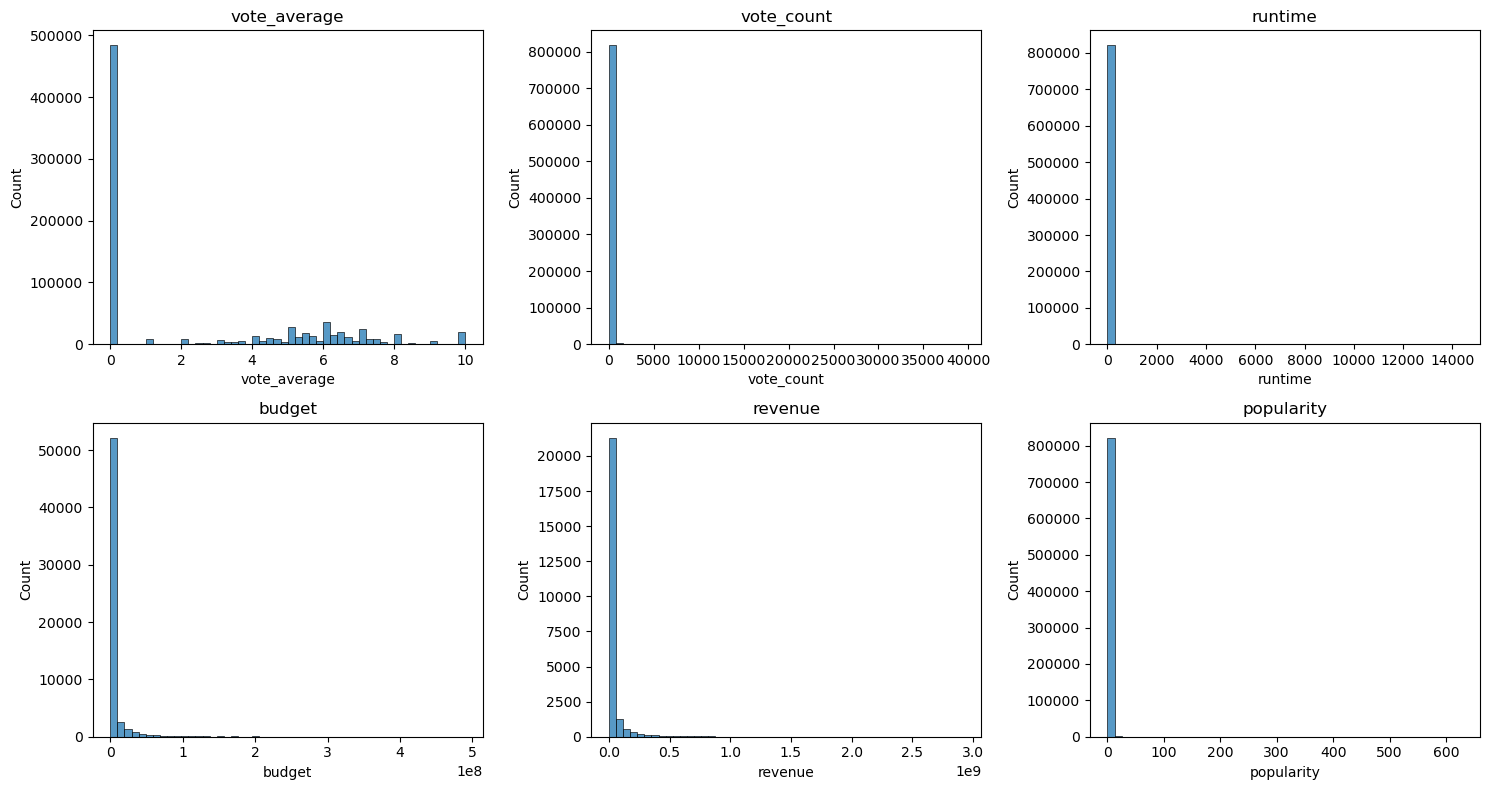

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["vote_average", "vote_count", "runtime", "budget", "revenue", "popularity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [53]:

df[["runtime", "popularity", "revenue", "vote_count"]].min()


runtime        1.0
popularity     0.0
revenue      -12.0
vote_count     0.0
dtype: float64

In [55]:
df[["runtime", "popularity", "revenue", "vote_count"]].max()

runtime       1.440000e+04
popularity    6.287419e+02
revenue       2.923706e+09
vote_count    3.948300e+04
dtype: float64

In [63]:
df[df["runtime"] > 300][["title", "runtime"]].head()

,title,runtime
2256,1900,317.0
2365,The French Revolution,335.0
6401,The Best of Youth,367.0
6497,The Legend of Till,311.0
7227,UFC 87: Seek and Destroy,342.0


In [65]:

df.sort_values("runtime", ascending=False)[["title", "runtime"]].head(10)

,title,runtime
129538,Modern Times Forever,14400.0
399846,Svalbard minutt for minutt,13319.0
143189,Cinématon,12480.0
105125,Beijing 2003,9000.0
403308,Untitled #125 (Hickory),7200.0
187469,Matrjoschka,5700.0
109107,Giant 600 Cartoon Collection,3720.0
157376,The Longest Most Meaningless Movie in the World,2880.0
216524,350 Classic Cartoons,2400.0
283352,6144 x 1024,2182.0


In [67]:
# Before filtering
print("Before:", df.shape)

# Keep only movies with runtime between 60 and 300 minutes
df = df[(df["runtime"] >= 60) & (df["runtime"] <= 300)]

# After filtering
print("After:", df.shape)

# Verify
print(df["runtime"].describe())

Before: (822873, 19)
After: (409891, 19)
count    409891.000000
mean         96.391155
std          27.406341
min          60.000000
25%          80.000000
50%          91.000000
75%         105.000000
max         300.000000
Name: runtime, dtype: float64


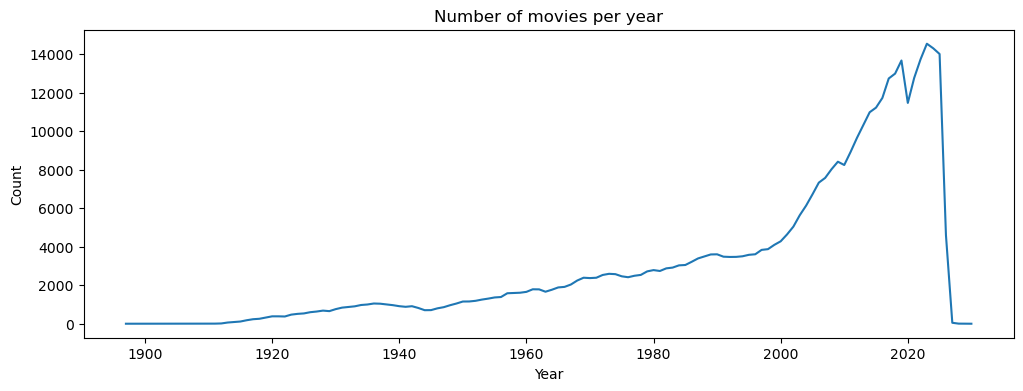

In [69]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.lineplot(x=year_counts.index, y=year_counts.values)
plt.title("Number of movies per year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [71]:
df["original_language"].value_counts().head(10)

original_language
en    188465
ja     30283
es     22910
fr     20464
de     16168
ru     10806
it     10741
zh     10548
ko      7373
pt      6653
Name: count, dtype: int64

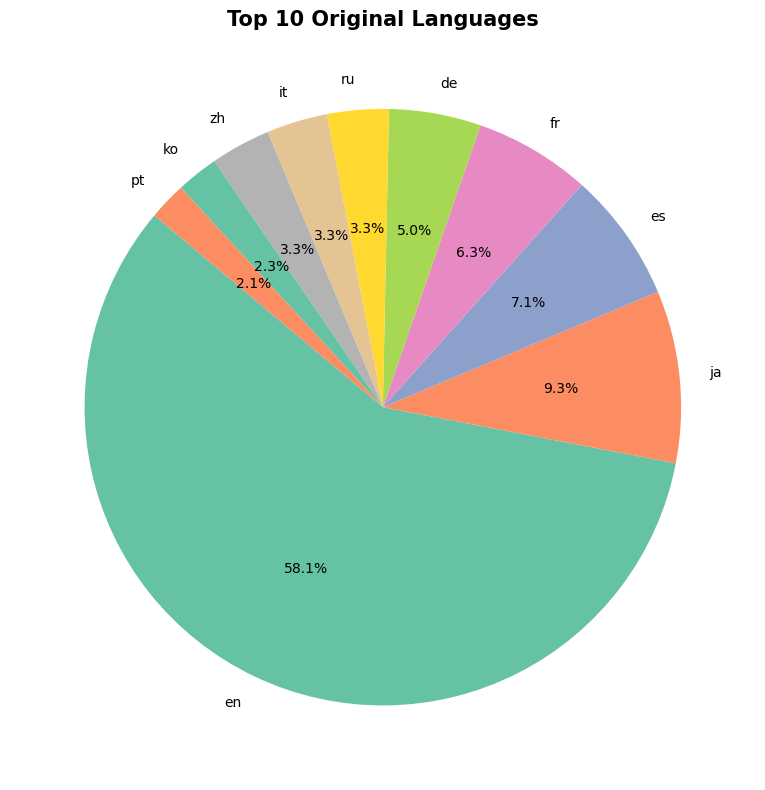

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
lang_counts = df["original_language"].value_counts().head(10)

plt.figure(figsize=(8, 8))
plt.pie(
    lang_counts.values,
    labels=lang_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2", len(lang_counts))
)
plt.title("Top 10 Original Languages", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [73]:
df["status"].value_counts()

status
Released           409395
Post Production       246
In Production         222
Planned                25
Rumored                 2
Canceled                1
Name: count, dtype: int64

In [75]:
from collections import Counter

genre_counter = Counter()
for g in df["genres"]:
    for item in str(g).split(","):
        item = item.strip()
        if item:
            genre_counter[item] += 1

genre_df = (
    pd.DataFrame.from_dict(genre_counter, orient="index", columns=["count"])
      .sort_values("count", ascending=False)
)

genre_df.head(15)

,count
Drama,151654
Comedy,84534
Documentary,67748
nan,46131
Romance,41422
Thriller,36596
Action,34626
Horror,32477
Music,28349
Crime,28148


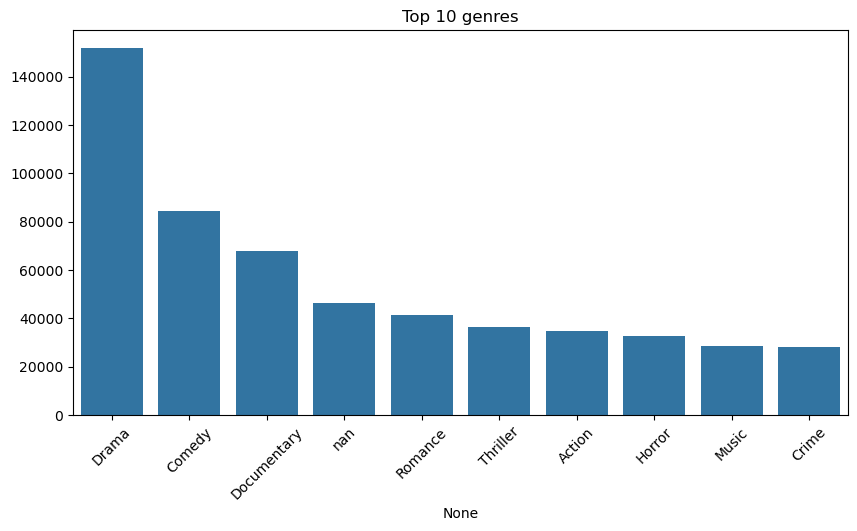

In [77]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=genre_df.head(10).index,
    y=genre_df.head(10)["count"].values
)
plt.xticks(rotation=45)
plt.title("Top 10 genres")
plt.show()

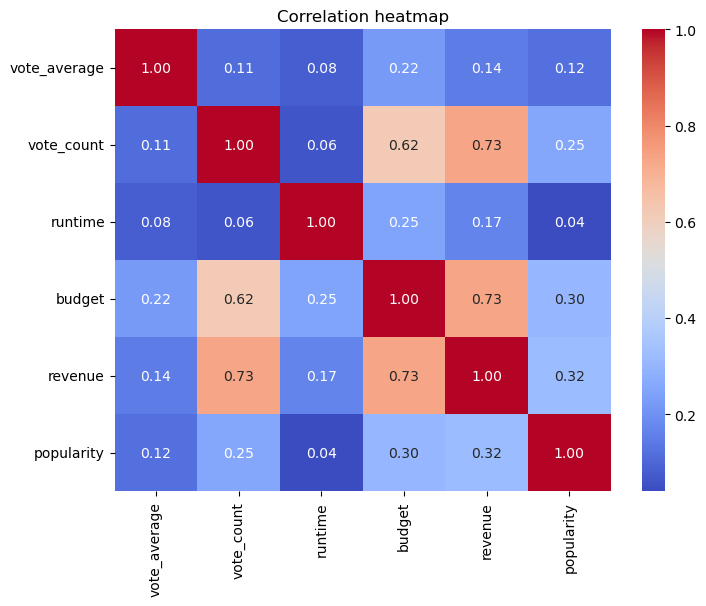

In [79]:
corr = df[["vote_average", "vote_count", "runtime", "budget", "revenue", "popularity"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

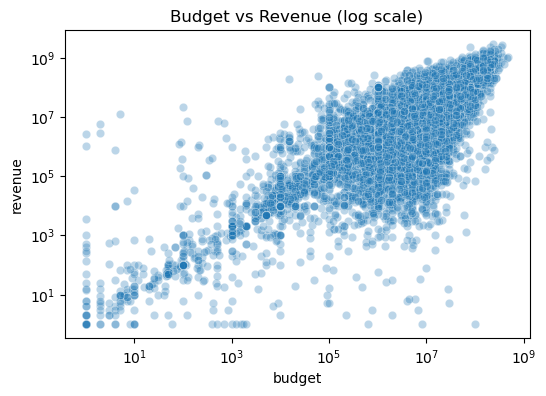

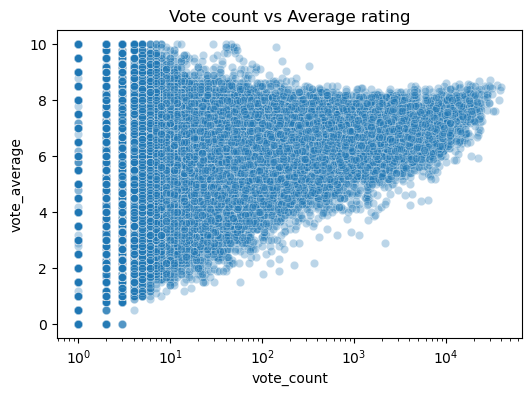

In [81]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs Revenue (log scale)")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="vote_count", y="vote_average", alpha=0.3)
plt.xscale("log")
plt.title("Vote count vs Average rating")
plt.show()

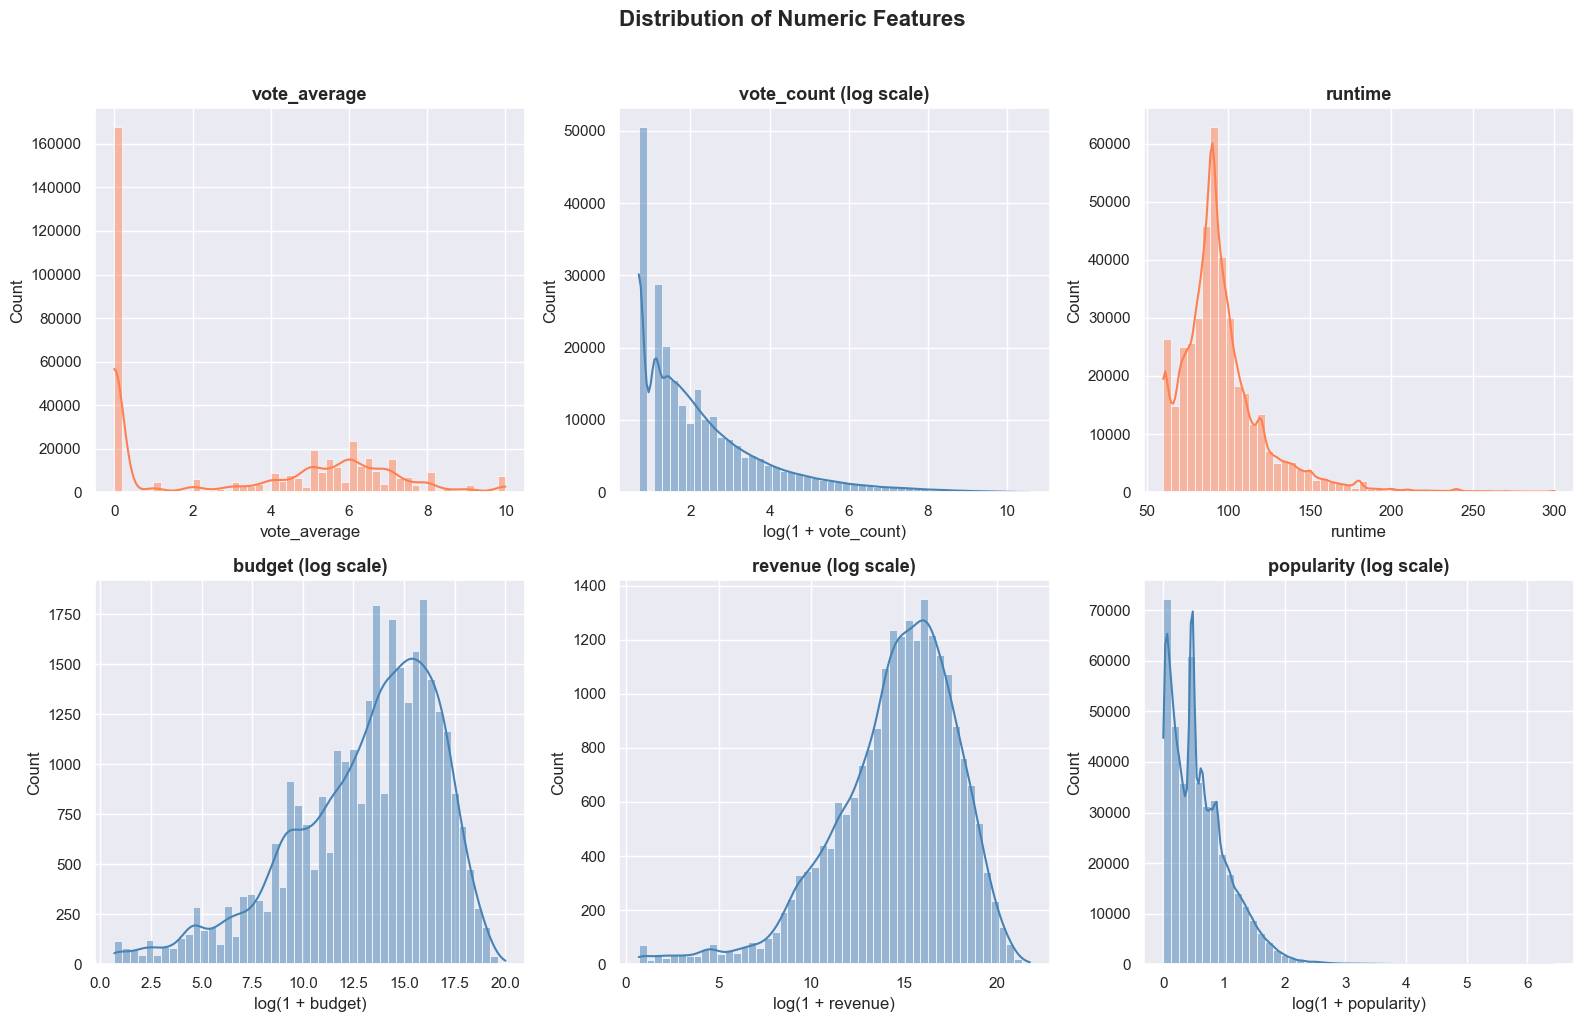

In [87]:
sns.set_theme(style="darkgrid", palette="muted")

# ── 1. DISTRIBUTION PLOTS WITH KDE (better than plain histplot) ──────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

num_cols = ["vote_average", "vote_count", "runtime", "budget", "revenue", "popularity"]

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    # Use log scale for skewed columns
    if col in ["vote_count", "budget", "revenue", "popularity"]:
        data = data[data > 0]
        sns.histplot(np.log1p(data), kde=True, ax=ax, color="steelblue", bins=50)
        ax.set_title(f"{col} (log scale)", fontsize=13, fontweight="bold")
        ax.set_xlabel(f"log(1 + {col})")
    else:
        sns.histplot(data, kde=True, ax=ax, color="coral", bins=50)
        ax.set_title(col, fontsize=13, fontweight="bold")

plt.suptitle("Distribution of Numeric Features", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


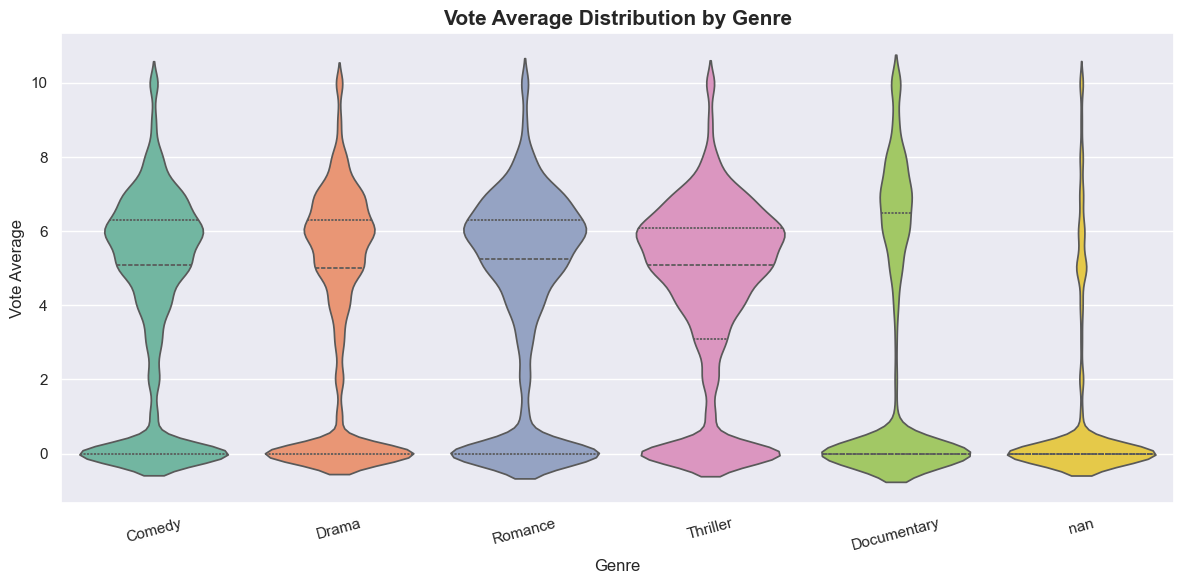

In [89]:
top_genres = [g for g, _ in genre_counter.most_common(6)]

rows = []
for _, row in df.iterrows():
    for g in str(row["genres"]).split(","):
        g = g.strip()
        if g in top_genres:
            rows.append({"genre": g, "vote_average": row["vote_average"]})

genre_rating_df = pd.DataFrame(rows)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=genre_rating_df,
    x="genre",
    y="vote_average",
    palette="Set2",
    inner="quartile"
)
plt.title("Vote Average Distribution by Genre", fontsize=15, fontweight="bold")
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Vote Average", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [91]:
df.shape

(409891, 19)

In [93]:

df.to_csv("tmdb_cleaned_with_eda.csv", index=False)
df.head()

,id,title,status,original_title,release_date,release_year,vote_average,vote_count,runtime,budget,revenue,original_language,genres,cast,director,overview,tagline,popularity,tags
0,2,Ariel,Released,Ariel,1988-10-21,1988.0,7.106,371.0,73.0,NaN,NaN,fi,"Comedy, Drama, Romance, Crime","Kari Helaseppä, Jaakko Talaskivi, Mikko Remes,...",Aki Kaurismäki,A Finnish man goes to the city to find a job a...,NaN,1.6384,"comedy, drama, romance, crime kari helaseppä, ..."
1,3,Shadows in Paradise,Released,Varjoja paratiisissa,1986-10-17,1986.0,7.300,435.0,74.0,NaN,NaN,fi,"Comedy, Drama, Romance","Ari Korhonen, Mari Rantasila, Erkki Rissanen, ...",Aki Kaurismäki,"Nikander, a rubbish collector and would-be ent...",NaN,2.7136,"comedy, drama, romance ari korhonen, mari rant..."
2,5,Four Rooms,Released,Four Rooms,1995-12-09,1995.0,5.900,2821.0,98.0,4000000.0,4257354.0,en,Comedy,"David Proval, Tamlyn Tomita, Paul Skemp, Lana ...","Quentin Tarantino, Robert Rodriguez, Alexandre...",It's Ted the Bellhop's first night on the job....,Twelve outrageous guests. Four scandalous requ...,4.0661,"comedy david proval, tamlyn tomita, paul skemp..."
3,6,Judgment Night,Released,Judgment Night,1993-10-15,1993.0,6.500,370.0,109.0,21000000.0,12136938.0,en,"Action, Crime, Thriller","Jeremy Piven, Lydell M. Cheshier, Michael DeLo...",Stephen Hopkins,"Four young friends, while taking a shortcut en...",Don't move. Don't whisper. Don't even breathe.,2.1596,"action, crime, thriller jeremy piven, lydell m..."
4,8,Life in Loops (A Megacities RMX),Released,Life in Loops (A Megacities RMX),2006-01-01,2006.0,7.200,30.0,80.0,42000.0,NaN,en,Documentary,NaN,Timo Novotny,Timo Novotny labels his new project an experim...,A Megacities remix.,2.2585,documentary timo novotny timo novotny labels ...
